# Final Report and Figures for Discovery Quality Mediation

This notebook closes the discovery-quality mediation analysis. Earlier notebooks built the dataset, constructed discovery and satisfaction metrics, defined mediation estimands, estimated direct and indirect effects, tested robustness, and compared advanced model families.

This notebook does three things:

- Pulls the final evidence into a concise set of report tables and figures.
- Writes a portfolio-ready markdown summary and resume bullets.
- Creates an artifact index so the project is easy to navigate later.

The final story is intentionally balanced: high discovery exposure is associated with higher future user value in the linear and SEM-style analyses; flexible ML models keep the sign positive but shrink the effect size. Across specifications, the satisfaction-depth mediated pathway is small relative to the direct pathway.

## 1. Load Libraries and Paths

This cell imports the report-building libraries and defines the project paths. The final notebook mostly reads saved outputs and writes final artifacts, so the path setup is the most important piece of infrastructure here.

In [1]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "discovery_quality_mediation"
WRITEUP_DIR = NOTEBOOK_DIR / "writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_SUMMARY_OUTPUT = WRITEUP_DIR / "final_project_summary.md"
RESUME_BULLETS_OUTPUT = WRITEUP_DIR / "resume_bullets.md"
ARTIFACT_INDEX_OUTPUT = WRITEUP_DIR / "artifact_index.csv"
FINAL_EXECUTIVE_TABLE_OUTPUT = TABLE_DIR / "final_executive_summary.csv"
FINAL_MAIN_EFFECTS_OUTPUT = TABLE_DIR / "final_main_effects.csv"
FINAL_ROBUSTNESS_OUTPUT = TABLE_DIR / "final_robustness_snapshot.csv"
FINAL_ADVANCED_OUTPUT = TABLE_DIR / "final_advanced_model_snapshot.csv"
FINAL_LIMITATIONS_OUTPUT = TABLE_DIR / "final_limitations.csv"

The output paths are all inside this project's `writeup` folder, except for the processed inputs that were created by earlier notebooks. This keeps the final report self-contained.

## 2. Load Final Analysis Artifacts

This cell loads the outputs produced across notebooks 01-06. These files are the source of truth for the final report: data readiness, metric definitions, assumptions, effect estimates, robustness checks, advanced model comparisons, and limitations.

In [2]:
inputs = {
    "readiness": PROCESSED_DIR / "kuairec_discovery_quality_readiness.csv",
    "selected_metrics": PROCESSED_DIR / "kuairec_discovery_quality_selected_metrics.csv",
    "metric_registry": PROCESSED_DIR / "kuairec_discovery_quality_metric_registry.csv",
    "assumption_checks": PROCESSED_DIR / "kuairec_discovery_quality_assumption_checks.csv",
    "effect_summary": PROCESSED_DIR / "kuairec_discovery_quality_effect_summary.csv",
    "controlled_direct_effects": PROCESSED_DIR / "kuairec_discovery_quality_controlled_direct_effects.csv",
    "robustness_summary": PROCESSED_DIR / "kuairec_discovery_quality_robustness_summary.csv",
    "threshold_robustness": PROCESSED_DIR / "kuairec_discovery_quality_robustness_thresholds.csv",
    "mediator_robustness": PROCESSED_DIR / "kuairec_discovery_quality_robustness_mediators.csv",
    "model_sensitivity": PROCESSED_DIR / "kuairec_discovery_quality_model_sensitivity.csv",
    "continuous_sensitivity": PROCESSED_DIR / "kuairec_discovery_quality_continuous_score_sensitivity.csv",
    "placebo_checks": PROCESSED_DIR / "kuairec_discovery_quality_placebo_checks.csv",
    "advanced_summary": PROCESSED_DIR / "kuairec_discovery_quality_advanced_model_summary.csv",
    "advanced_ml_effects": PROCESSED_DIR / "kuairec_discovery_quality_advanced_ml_effects.csv",
    "advanced_performance": PROCESSED_DIR / "kuairec_discovery_quality_advanced_ml_performance.csv",
    "advanced_heterogeneity": PROCESSED_DIR / "kuairec_discovery_quality_advanced_heterogeneity.csv",
    "limitations": PROCESSED_DIR / "kuairec_discovery_quality_limitations.csv",
}

loaded = {name: pd.read_csv(path) for name, path in inputs.items()}
load_summary = pd.DataFrame(
    {
        "artifact": list(inputs.keys()),
        "path": [str(path) for path in inputs.values()],
        "rows": [len(loaded[name]) for name in inputs.keys()],
        "columns": [loaded[name].shape[1] for name in inputs.keys()],
    }
)

display(load_summary)

,artifact,path,rows,columns
0,readiness,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_readiness.csv,6,3
1,selected_metrics,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_selected_metrics.csv,4,7
2,metric_registry,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_metric_registry.csv,6,5
3,assumption_checks,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_assumption_checks.csv,6,5
4,effect_summary,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_effect_summary.csv,21,12
5,controlled_direct_effects,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_controlled_direct_effects.csv,9,7
6,robustness_summary,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_robustness_summary.csv,4,9
7,threshold_robustness,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_robustness_thresholds.csv,4,26
8,mediator_robustness,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_robustness_mediators.csv,5,25
9,model_sensitivity,/home/apex/Documents/ranking_sys/data/processed/kuairec_discovery_quality_model_sensitivity.csv,5,25


The load summary confirms that the final notebook is not doing fresh causal estimation. It is assembling the outputs that were already created and validated earlier.

## 3. Build the Executive Summary Table

This cell creates a compact executive summary. It captures the dataset scale, primary estimand, main result, robustness finding, advanced-model finding, and central caveat.

In [3]:
readiness = loaded["readiness"]
effect_summary = loaded["effect_summary"]
robustness_summary = loaded["robustness_summary"]
advanced_summary = loaded["advanced_summary"]
limitations = loaded["limitations"]

primary_total = effect_summary.query(
    "outcome == 'Y_future_interactions' and estimand == 'gcomp_total_effect'"
).iloc[0]
primary_direct = effect_summary.query(
    "outcome == 'Y_future_interactions' and estimand == 'natural_direct_effect'"
).iloc[0]
primary_indirect = effect_summary.query(
    "outcome == 'Y_future_interactions' and estimand == 'natural_indirect_effect'"
).iloc[0]
play_hours_total = effect_summary.query(
    "outcome == 'Y_future_play_hours' and estimand == 'gcomp_total_effect'"
).iloc[0]

active_user_days = int(readiness.loc[readiness["check"].eq("active_user_days"), "value"].iloc[0])
sampled_users = int(readiness.loc[readiness["check"].eq("sampled_users"), "value"].iloc[0])

threshold_row = robustness_summary.query("robustness_family == 'threshold_sensitivity'").iloc[0]
model_row = robustness_summary.query("robustness_family == 'model_sensitivity'").iloc[0]
lightgbm_row = advanced_summary.query("model_family == 'lightgbm'").iloc[0]
xgboost_row = advanced_summary.query("model_family == 'xgboost'").iloc[0]

executive_summary = pd.DataFrame(
    [
        {"item": "Analysis unit", "summary": f"{active_user_days:,} active user-days from {sampled_users:,} KuaiRec users."},
        {"item": "Treatment", "summary": "High discovery-breadth day, based on long-tail exposure, new category exposure, and category breadth."},
        {"item": "Mediator", "summary": "Same-day satisfaction depth, combining watch-ratio, valid-play, completion, and abandonment proxies."},
        {"item": "Primary outcome", "summary": "Future seven-day interactions after the current active day."},
        {"item": "Main total effect", "summary": f"+{primary_total['estimate']:.1f} future interactions, 95% bootstrap interval [{primary_total['ci_95_lower']:.1f}, {primary_total['ci_95_upper']:.1f}]."},
        {"item": "Direct pathway", "summary": f"+{primary_direct['estimate']:.1f} future interactions, larger than the total because the mediated pathway is slightly negative."},
        {"item": "Satisfaction-mediated pathway", "summary": f"{primary_indirect['estimate']:.1f} future interactions, about {primary_total['proportion_mediated']:.1%} of the total effect."},
        {"item": "Play-time outcome", "summary": f"+{play_hours_total['estimate']:.3f} future play hours, with a small positive mediated pathway."},
        {"item": "Robustness", "summary": f"Threshold tests kept the total effect positive across {int(threshold_row['specifications'])} specifications; model sensitivity range was {model_row['total_effect_min']:.1f} to {model_row['total_effect_max']:.1f}."},
        {"item": "Advanced models", "summary": f"LightGBM and XGBoost kept the sign positive but shrank total effects to +{lightgbm_row['total_effect']:.1f} and +{xgboost_row['total_effect']:.1f}."},
        {"item": "Main caveat", "summary": "The logs are observational, so unobserved user intent and ranking-system state can still confound the estimates."},
    ]
)

display(executive_summary)

,item,summary
0,Analysis unit,"8,199 active user-days from 133 KuaiRec users."
1,Treatment,"High discovery-breadth day, based on long-tail exposure, new category exposure, and category breadth."
2,Mediator,"Same-day satisfaction depth, combining watch-ratio, valid-play, completion, and abandonment proxies."
3,Primary outcome,Future seven-day interactions after the current active day.
4,Main total effect,"+37.3 future interactions, 95% bootstrap interval [32.2, 42.8]."
5,Direct pathway,"+38.6 future interactions, larger than the total because the mediated pathway is slightly negative."
6,Satisfaction-mediated pathway,"-1.3 future interactions, about -3.5% of the total effect."
7,Play-time outcome,"+0.078 future play hours, with a small positive mediated pathway."
8,Robustness,Threshold tests kept the total effect positive across 4 specifications; model sensitivity range was 34.8 to 37.6.
9,Advanced models,LightGBM and XGBoost kept the sign positive but shrank total effects to +3.2 and +2.7.


The executive summary is deliberately concise. It is meant to be readable without requiring someone to open every intermediate notebook.

## 4. Present the Metric Roles

This cell turns the selected metric table into a final report table. It clarifies which metric served as exposure, mediator, product monitoring score, and guardrail.

In [4]:
selected_metrics = loaded["selected_metrics"].copy()
metric_roles = selected_metrics[
    ["selected_for", "metric", "reason", "future_alignment_score", "history_dependence_score", "screening_score"]
].copy()
metric_roles["selected_for"] = metric_roles["selected_for"].str.replace("_", " ").str.title()
metric_roles = metric_roles.rename(
    columns={
        "selected_for": "Role",
        "metric": "Metric",
        "reason": "Why it was selected",
        "future_alignment_score": "Future alignment",
        "history_dependence_score": "History dependence",
        "screening_score": "Screening score",
    }
)

display(metric_roles.round(4))

,Role,Metric,Why it was selected,Future alignment,History dependence,Screening score
0,Exposure Analysis,discovery_breadth_score,Purest discovery exposure score; does not use future outcomes or satisfaction depth as a defining component.,0.5015,0.4008,0.3612
1,Mediator Analysis,satisfaction_depth_score,Aggregates several same-day quality signals and is appropriate as a mediator candidate.,0.0510,0.0465,0.0347
2,Product Metric Monitoring,quality_adjusted_discovery_score,"Requires both discovery breadth and satisfaction depth to be high, making it a useful composite quality metric.",0.4924,0.3574,0.3673
3,Guardrail Monitoring,shallow_click_pressure_score,"Flags high-volume days with low satisfaction, useful as a warning against click-only optimization.",0.3316,0.4440,0.1762


The key design choice is that the exposure metric and mediator metric stay separate. That separation is what makes the mediation decomposition understandable.

## 5. Create the Final Main Effects Table

This cell builds the final direct, indirect, and total effect table for the primary outcome and the play-hours outcome. These are the headline estimates from notebook 04.

In [5]:
final_effects = effect_summary.query(
    "estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect', 'mediator_shift_M1_minus_M0']"
).copy()
final_effects["Estimand"] = final_effects["estimand"].map(
    {
        "gcomp_total_effect": "Total effect",
        "natural_direct_effect": "Natural direct effect",
        "natural_indirect_effect": "Natural indirect effect",
        "mediator_shift_M1_minus_M0": "Satisfaction-depth shift",
    }
)
final_effects = final_effects[
    [
        "outcome_label",
        "Estimand",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "relative_effect",
        "proportion_mediated",
    ]
].rename(
    columns={
        "outcome_label": "Outcome",
        "estimate": "Estimate",
        "ci_95_lower": "CI lower",
        "ci_95_upper": "CI upper",
        "relative_effect": "Relative effect",
        "proportion_mediated": "Proportion mediated",
    }
)

# The mediator shift is on a different scale, so relative effect and proportion mediated are not reported for that row.
final_effects.loc[final_effects["Estimand"].eq("Satisfaction-depth shift"), ["Relative effect", "Proportion mediated"]] = np.nan

display(final_effects.round(4))

,Outcome,Estimand,Estimate,CI lower,CI upper,Relative effect,Proportion mediated
2,Future 7-day interactions,Total effect,37.2781,32.2444,42.8135,0.1152,-0.0351
3,Future 7-day interactions,Natural direct effect,38.5858,33.3634,43.7154,0.1192,-0.0351
4,Future 7-day interactions,Natural indirect effect,-1.3077,-2.3047,-0.4290,-0.0036,-0.0351
6,Future 7-day interactions,Satisfaction-depth shift,0.0231,0.0185,0.0279,NaN,NaN
9,Future 7-day active days,Total effect,0.0074,-0.0452,0.0631,0.0011,0.7175
10,Future 7-day active days,Natural direct effect,0.0021,-0.0449,0.0648,0.0003,0.7175
11,Future 7-day active days,Natural indirect effect,0.0053,-0.0145,0.0201,0.0008,0.7175
13,Future 7-day active days,Satisfaction-depth shift,0.0231,0.0185,0.0279,NaN,NaN
16,Future 7-day play hours,Total effect,0.0784,0.0689,0.0954,0.1000,0.0562
17,Future 7-day play hours,Natural direct effect,0.0739,0.0630,0.0927,0.0943,0.0562


This table makes the main project finding explicit: the future-interaction effect is positive, and the satisfaction-depth pathway is small compared with the direct pathway.

## 6. Plot the Final Effect Decomposition

This cell creates a clean final figure for the primary outcome. The plot shows total, direct, and indirect effects with bootstrap intervals.

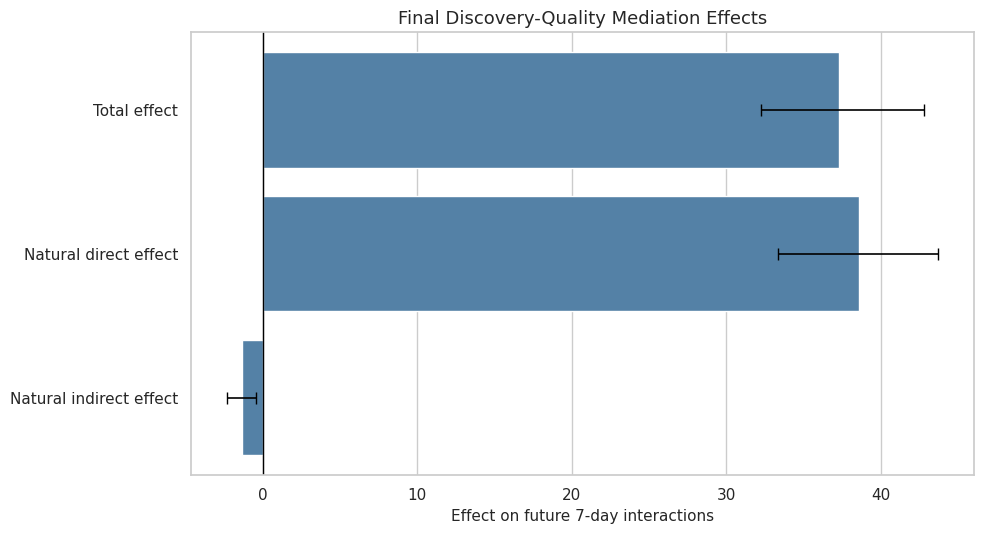

In [6]:
main_plot = final_effects.query(
    "Outcome == 'Future 7-day interactions' and Estimand in ['Total effect', 'Natural direct effect', 'Natural indirect effect']"
).copy()
main_plot["lower_error"] = main_plot["Estimate"] - main_plot["CI lower"]
main_plot["upper_error"] = main_plot["CI upper"] - main_plot["Estimate"]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=main_plot, x="Estimate", y="Estimand", color="steelblue", ax=ax)
for row_index, row in main_plot.reset_index(drop=True).iterrows():
    ax.errorbar(
        x=row["Estimate"],
        y=row_index,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.2,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Discovery-Quality Mediation Effects")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("")
plt.tight_layout()
final_effect_figure = FIGURE_DIR / "26_final_effect_decomposition.png"
fig.savefig(final_effect_figure, dpi=160, bbox_inches="tight")
plt.show()

This is the primary report figure. It shows that the main result is driven by the direct path rather than a large satisfaction-mediated path.

## 7. Summarize Robustness Evidence

This cell creates a final robustness snapshot from threshold, mediator, model, and outcome sensitivity tables. The focus is whether the total effect remains positive and whether the indirect pathway stays small.

In [7]:
robustness_snapshot = robustness_summary.copy()
robustness_snapshot["Robustness family"] = robustness_snapshot["robustness_family"].str.replace("_", " ").str.title()
robustness_snapshot = robustness_snapshot[
    [
        "Robustness family",
        "specifications",
        "total_effect_min",
        "total_effect_max",
        "total_effect_share_positive",
        "indirect_effect_min",
        "indirect_effect_max",
        "median_abs_indirect_to_total_ratio",
    ]
].rename(
    columns={
        "specifications": "Specifications",
        "total_effect_min": "Total min",
        "total_effect_max": "Total max",
        "total_effect_share_positive": "Share total positive",
        "indirect_effect_min": "Indirect min",
        "indirect_effect_max": "Indirect max",
        "median_abs_indirect_to_total_ratio": "Median abs indirect/total",
    }
)

display(robustness_snapshot.round(4))

,Robustness family,Specifications,Total min,Total max,Share total positive,Indirect min,Indirect max,Median abs indirect/total
0,Threshold Sensitivity,4,37.2781,40.0555,1.0,-1.6532,-1.3077,0.0402
1,Mediator Sensitivity,5,37.2560,37.3502,1.0,-1.7145,0.1281,0.0359
2,Model Sensitivity,5,34.8085,37.6289,1.0,-1.5581,-0.9360,0.0351
3,Outcome Sensitivity,1,37.2781,37.2781,1.0,-1.3077,-1.3077,0.0351


The robustness snapshot supports a careful conclusion: the positive future-interaction association is stable across standard sensitivity checks, while the mediated pathway remains small.

## 8. Plot Robustness Ranges

This cell visualizes the range of total and indirect effects across robustness families. The goal is to show the reader where the result is stable and where it is sensitive.

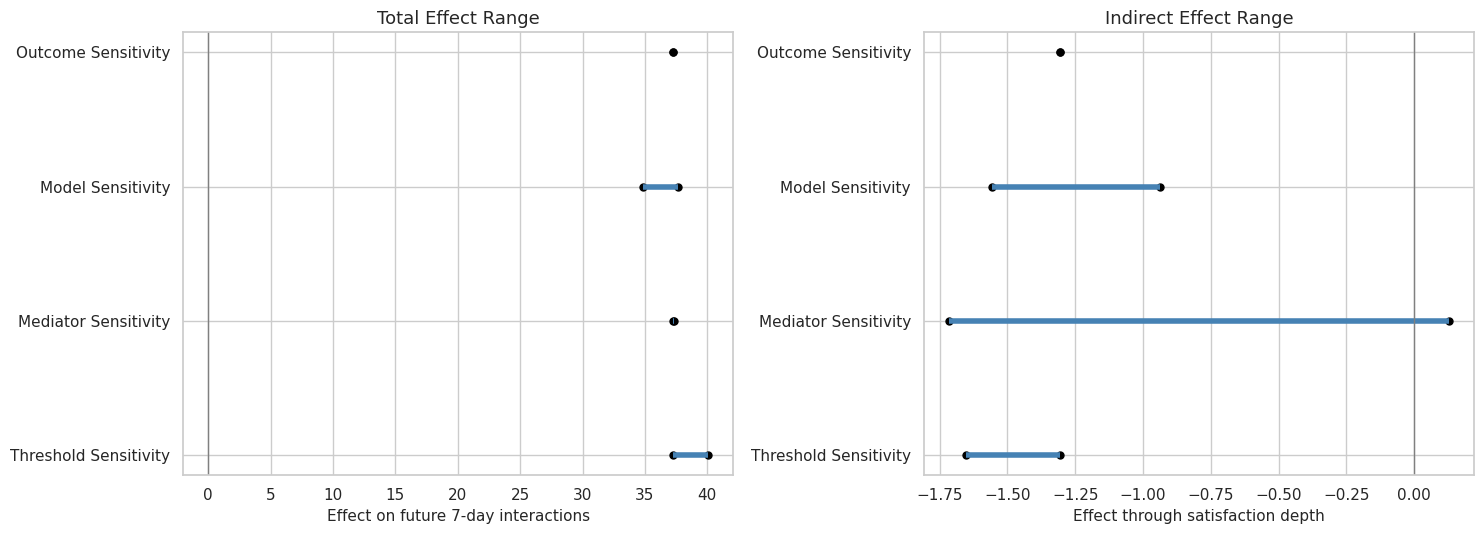

In [8]:
robustness_plot = robustness_snapshot.copy()
robustness_plot["Family"] = robustness_plot["Robustness family"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, lower_col, upper_col, title, xlabel in [
    (axes[0], "Total min", "Total max", "Total Effect Range", "Effect on future 7-day interactions"),
    (axes[1], "Indirect min", "Indirect max", "Indirect Effect Range", "Effect through satisfaction depth"),
]:
    y_positions = np.arange(len(robustness_plot))
    ax.hlines(
        y=y_positions,
        xmin=robustness_plot[lower_col],
        xmax=robustness_plot[upper_col],
        color="steelblue",
        linewidth=4,
    )
    ax.scatter(robustness_plot[lower_col], y_positions, color="black", s=25)
    ax.scatter(robustness_plot[upper_col], y_positions, color="black", s=25)
    ax.axvline(0, color="gray", linewidth=1)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(robustness_plot["Family"])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")

plt.tight_layout()
final_robustness_figure = FIGURE_DIR / "27_final_robustness_ranges.png"
fig.savefig(final_robustness_figure, dpi=160, bbox_inches="tight")
plt.show()

The range plot makes the robustness story easy to scan: total effects stay positive, while indirect effects remain near zero or modestly negative in the primary future-interaction setup.

## 9. Present Advanced Model Evidence

This cell prepares the final advanced model comparison. It includes the linear reference, SEM-style path model, cross-fitted linear model, and cross-fitted LightGBM/XGBoost models.

In [9]:
advanced_snapshot = advanced_summary.copy()
advanced_snapshot["Model approach"] = advanced_snapshot["model_family"].str.replace("_", " ").str.title()
advanced_snapshot = advanced_snapshot[
    [
        "Model approach",
        "total_effect",
        "direct_effect",
        "indirect_effect",
        "indirect_to_total_ratio",
        "total_effect_positive",
        "indirect_effect_small_abs_lt_5",
    ]
].rename(
    columns={
        "total_effect": "Total effect",
        "direct_effect": "Direct effect",
        "indirect_effect": "Indirect effect",
        "indirect_to_total_ratio": "Indirect/total",
        "total_effect_positive": "Total positive",
        "indirect_effect_small_abs_lt_5": "Small indirect effect",
    }
)

display(advanced_snapshot.round(4))

,Model approach,Total effect,Direct effect,Indirect effect,Indirect/total,Total positive,Small indirect effect
0,Linear Reference From Notebook 04,37.2781,38.5858,-1.3077,-0.0351,True,True
1,Sem Style Path Model,37.3139,38.4311,-1.1172,-0.0299,True,True
2,Linear,37.3421,38.6464,-1.3043,-0.0349,True,True
3,Lightgbm,3.2069,3.2652,-0.0583,-0.0182,True,True
4,Xgboost,2.6829,2.7279,-0.0450,-0.0168,True,True


The advanced models are the main nuance in the final story. Flexible nuisance models still produce positive total effects, but their effect sizes are much smaller than the linear/SEM estimates.

## 10. Plot Advanced Model Comparison

This cell creates the final advanced-model figure. It compares total, direct, and indirect effects across modeling approaches.

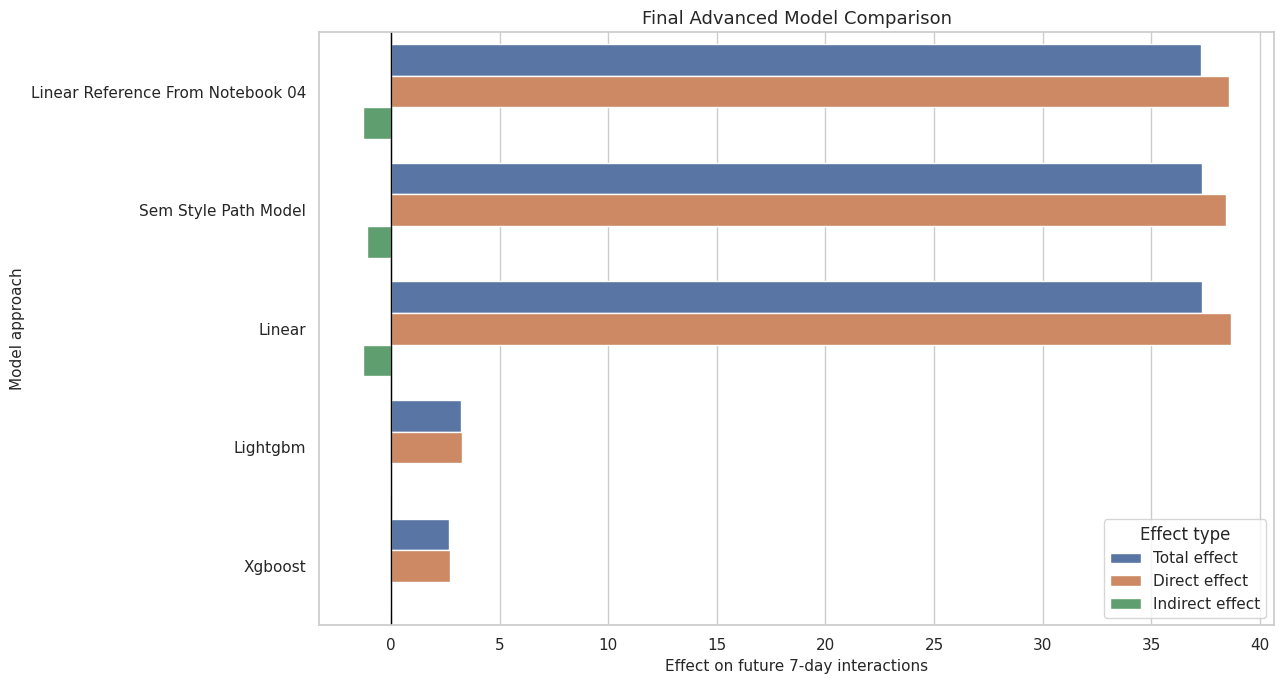

In [10]:
advanced_plot = advanced_snapshot.melt(
    id_vars=["Model approach"],
    value_vars=["Total effect", "Direct effect", "Indirect effect"],
    var_name="Effect type",
    value_name="Estimate",
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=advanced_plot, x="Estimate", y="Model approach", hue="Effect type", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Advanced Model Comparison")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("Model approach")
plt.tight_layout()
final_advanced_figure = FIGURE_DIR / "28_final_advanced_model_comparison.png"
fig.savefig(final_advanced_figure, dpi=160, bbox_inches="tight")
plt.show()

This figure prevents overclaiming from the linear model alone. It shows the positive direction is stable, but the magnitude is model-sensitive.

## 11. Final Limitations Table

This cell formats the limitations table created in notebook 05. It is included in the final report because the project uses observational recommendation logs and proxy satisfaction labels.

In [11]:
final_limitations = limitations.copy()
final_limitations["Limitation"] = final_limitations["limitation"].str.replace("_", " ").str.title()
final_limitations = final_limitations[
    ["Limitation", "why_it_matters", "mitigation_in_this_work", "remaining_risk"]
].rename(
    columns={
        "why_it_matters": "Why it matters",
        "mitigation_in_this_work": "Mitigation in this work",
        "remaining_risk": "Remaining risk",
    }
)

display(final_limitations)

,Limitation,Why it matters,Mitigation in this work,Remaining risk
0,Observational Recommendation Logs,"High-discovery exposure was not randomized, so user preferences and recommender selection can confound estimates.","Used pre-treatment history/profile controls, propensity diagnostics, and weighted sensitivity checks.",Unobserved ranking-system state and user intent can still bias estimates.
1,Mediator Outcome Confounding,Satisfaction depth and future engagement may share unobserved causes.,Checked residual mediator-outcome relationships and compared multiple mediator definitions.,Natural direct and indirect effects rely on strong mediator assumptions.
2,Satisfaction Proxy Measurement,"Watch ratio and valid play are proxies, not direct surveys of satisfaction.","Compared composite satisfaction, high watch ratio, valid play, average score, and completion-style mediators.","The chosen proxies may miss frustration, novelty value, or long-run satisfaction."
3,Active Day Sample Selection,"The analysis conditions on active user-days, so it does not study days with no observed interactions.",Defined the estimand clearly for active days and reported active-day alternate outcomes.,Results may not generalize to dormant users or cold-start retention decisions.
4,Calendar And History Imbalance,High discovery days differ from lower discovery days in time and recent behavior.,Included calendar/history controls and showed placebo-style pre-period checks.,Residual time-varying confounding can remain after observed adjustment.


The limitations table is part of the result, not an appendix afterthought. It defines what the analysis can and cannot support.

## 12. Write the Markdown Final Summary

This cell writes `final_project_summary.md`. The summary is intentionally concise and suitable for a repository README, portfolio page, or interview walkthrough.

In [12]:
summary_md = f"""
# Discovery Quality Mediation: Final Summary

## Problem

Recommendation systems can increase short-term activity without necessarily improving user satisfaction or durable value. This analysis studies whether high discovery exposure is associated with future user value, and whether that relationship is mediated by same-day satisfaction depth.

## Data and Unit of Analysis

- Dataset: KuaiRec interaction logs and metadata.
- Analysis unit: active user-day.
- Final analysis panel: {active_user_days:,} active user-days from {sampled_users:,} users.
- Treatment: high discovery-breadth day.
- Mediator: same-day satisfaction-depth score.
- Primary outcome: future seven-day interactions.

## Metrics

- `discovery_breadth_score`: exposure-like metric combining long-tail content, new category exposure, and category breadth.
- `satisfaction_depth_score`: mediator-like score combining watch quality, valid play, completion, and abandonment proxies.
- `quality_adjusted_discovery_score`: product monitoring metric that requires both discovery and satisfaction to be high.
- `shallow_click_pressure_score`: guardrail for high-volume, low-satisfaction engagement.

## Main Results

- Total effect on future seven-day interactions: **+{primary_total['estimate']:.1f}** with 95% bootstrap interval **[{primary_total['ci_95_lower']:.1f}, {primary_total['ci_95_upper']:.1f}]**.
- Natural direct effect: **+{primary_direct['estimate']:.1f}**.
- Natural indirect effect through satisfaction depth: **{primary_indirect['estimate']:.1f}**.
- Estimated shift in satisfaction depth from high discovery exposure: **+{effect_summary.query("outcome == 'Y_future_interactions' and estimand == 'mediator_shift_M1_minus_M0'")['estimate'].iloc[0]:.3f}**.
- Future play-hours total effect: **+{play_hours_total['estimate']:.3f}** hours.

The primary future-interaction gain is mostly direct in this specification. The satisfaction-depth mediated pathway is small relative to the total effect.

## Robustness

- Discovery-threshold sensitivity kept the total future-interaction effect positive across {int(threshold_row['specifications'])} tested thresholds.
- Mediator sensitivity kept the total effect positive across {int(robustness_summary.query("robustness_family == 'mediator_sensitivity'")['specifications'].iloc[0])} satisfaction proxy definitions.
- Model sensitivity kept the total effect positive across weighted/unweighted, interaction/no-interaction, and simple/rich control choices.
- Placebo-style checks show meaningful pre-period imbalance, which reinforces the need for adjustment and caution.

## Advanced Models

- SEM-style path model aligns closely with the linear g-computation result.
- Cross-fitted LightGBM and XGBoost keep the effect direction positive but shrink the estimated future-interaction effect to **+{lightgbm_row['total_effect']:.1f}** and **+{xgboost_row['total_effect']:.1f}**.
- The advanced model comparison supports a conservative conclusion: direction is stable, magnitude is model-sensitive.

## Limitations

- The data are observational recommendation logs, not randomized experiments.
- Satisfaction is measured through watch-behavior proxies rather than direct survey labels.
- Unobserved user intent and ranking-system state may confound treatment, mediator, and outcome relationships.
- The analysis conditions on active user-days and may not generalize to dormant users.

## Bottom Line

High discovery exposure appears positively associated with future user value, especially future interaction volume and play time. The evidence for a large satisfaction-mediated pathway is weak in the primary interaction-count analysis. A careful product takeaway is to track discovery quality separately from satisfaction depth and to validate discovery policies with future-value metrics, not short-term clicks alone.
""".strip()

FINAL_SUMMARY_OUTPUT.write_text(summary_md + chr(10), encoding="utf-8")
display(Markdown(summary_md))

# Discovery Quality Mediation: Final Summary

## Problem

Recommendation systems can increase short-term activity without necessarily improving user satisfaction or durable value. This analysis studies whether high discovery exposure is associated with future user value, and whether that relationship is mediated by same-day satisfaction depth.

## Data and Unit of Analysis

- Dataset: KuaiRec interaction logs and metadata.
- Analysis unit: active user-day.
- Final analysis panel: 8,199 active user-days from 133 users.
- Treatment: high discovery-breadth day.
- Mediator: same-day satisfaction-depth score.
- Primary outcome: future seven-day interactions.

## Metrics

- `discovery_breadth_score`: exposure-like metric combining long-tail content, new category exposure, and category breadth.
- `satisfaction_depth_score`: mediator-like score combining watch quality, valid play, completion, and abandonment proxies.
- `quality_adjusted_discovery_score`: product monitoring metric that requires both discovery and satisfaction to be high.
- `shallow_click_pressure_score`: guardrail for high-volume, low-satisfaction engagement.

## Main Results

- Total effect on future seven-day interactions: **+37.3** with 95% bootstrap interval **[32.2, 42.8]**.
- Natural direct effect: **+38.6**.
- Natural indirect effect through satisfaction depth: **-1.3**.
- Estimated shift in satisfaction depth from high discovery exposure: **+0.023**.
- Future play-hours total effect: **+0.078** hours.

The primary future-interaction gain is mostly direct in this specification. The satisfaction-depth mediated pathway is small relative to the total effect.

## Robustness

- Discovery-threshold sensitivity kept the total future-interaction effect positive across 4 tested thresholds.
- Mediator sensitivity kept the total effect positive across 5 satisfaction proxy definitions.
- Model sensitivity kept the total effect positive across weighted/unweighted, interaction/no-interaction, and simple/rich control choices.
- Placebo-style checks show meaningful pre-period imbalance, which reinforces the need for adjustment and caution.

## Advanced Models

- SEM-style path model aligns closely with the linear g-computation result.
- Cross-fitted LightGBM and XGBoost keep the effect direction positive but shrink the estimated future-interaction effect to **+3.2** and **+2.7**.
- The advanced model comparison supports a conservative conclusion: direction is stable, magnitude is model-sensitive.

## Limitations

- The data are observational recommendation logs, not randomized experiments.
- Satisfaction is measured through watch-behavior proxies rather than direct survey labels.
- Unobserved user intent and ranking-system state may confound treatment, mediator, and outcome relationships.
- The analysis conditions on active user-days and may not generalize to dormant users.

## Bottom Line

High discovery exposure appears positively associated with future user value, especially future interaction volume and play time. The evidence for a large satisfaction-mediated pathway is weak in the primary interaction-count analysis. A careful product takeaway is to track discovery quality separately from satisfaction depth and to validate discovery policies with future-value metrics, not short-term clicks alone.

The markdown summary is now saved as a standalone report artifact. It captures the core problem, methods, results, robustness, advanced models, and caveats in one place.

## 13. Write Resume Bullets

This cell writes concise resume bullets based on the work. They are phrased broadly for data science, causal inference, and recommendation-system roles.

In [13]:
resume_md = f"""
# Resume Bullets

- Built an end-to-end causal mediation analysis on KuaiRec recommendation logs to study how discovery exposure, satisfaction depth, and future user value relate at the active user-day level.
- Engineered discovery-quality metrics separating exposure, mediator, composite product score, and guardrail roles; validated metrics against future engagement while avoiding future-label leakage.
- Estimated total, natural direct, natural indirect, and controlled direct effects with g-computation and user-level bootstrap uncertainty across {active_user_days:,} active user-days.
- Stress-tested mediation findings across treatment thresholds, mediator definitions, outcome definitions, weighting choices, interaction terms, control sets, and placebo-style pre-period checks.
- Compared linear mediation, SEM-style path modeling, and cross-fitted LightGBM/XGBoost nuisance models; found stable positive direction but model-sensitive effect magnitude.
- Produced portfolio-ready report artifacts, figures, limitations, and artifact index for a recommendation-system causal measurement workflow.
""".strip()

RESUME_BULLETS_OUTPUT.write_text(resume_md + chr(10), encoding="utf-8")
display(Markdown(resume_md))

# Resume Bullets

- Built an end-to-end causal mediation analysis on KuaiRec recommendation logs to study how discovery exposure, satisfaction depth, and future user value relate at the active user-day level.
- Engineered discovery-quality metrics separating exposure, mediator, composite product score, and guardrail roles; validated metrics against future engagement while avoiding future-label leakage.
- Estimated total, natural direct, natural indirect, and controlled direct effects with g-computation and user-level bootstrap uncertainty across 8,199 active user-days.
- Stress-tested mediation findings across treatment thresholds, mediator definitions, outcome definitions, weighting choices, interaction terms, control sets, and placebo-style pre-period checks.
- Compared linear mediation, SEM-style path modeling, and cross-fitted LightGBM/XGBoost nuisance models; found stable positive direction but model-sensitive effect magnitude.
- Produced portfolio-ready report artifacts, figures, limitations, and artifact index for a recommendation-system causal measurement workflow.

The resume bullets emphasize the skills demonstrated: metric construction, causal mediation, robust evaluation, advanced modeling, and report packaging.

## 14. Create the Artifact Index

This cell creates a project artifact index. The index makes it easy to find notebooks, processed data outputs, final tables, final figures, and markdown writeups.

In [14]:
artifact_rows = []

for notebook_path in sorted(NOTEBOOK_DIR.glob("*.ipynb")):
    artifact_rows.append(
        {
            "artifact_type": "notebook",
            "artifact": notebook_path.name,
            "path": str(notebook_path.relative_to(PROJECT_ROOT)),
            "description": "Discovery-quality mediation notebook.",
        }
    )

for table_path in sorted(TABLE_DIR.glob("*.csv")):
    artifact_rows.append(
        {
            "artifact_type": "writeup_table",
            "artifact": table_path.name,
            "path": str(table_path.relative_to(PROJECT_ROOT)),
            "description": "CSV table used by the final report or prior writeup notebooks.",
        }
    )

for figure_path in sorted(FIGURE_DIR.glob("*.png")):
    artifact_rows.append(
        {
            "artifact_type": "figure",
            "artifact": figure_path.name,
            "path": str(figure_path.relative_to(PROJECT_ROOT)),
            "description": "PNG figure generated by the discovery-quality notebooks.",
        }
    )

for markdown_path in [FINAL_SUMMARY_OUTPUT, RESUME_BULLETS_OUTPUT]:
    artifact_rows.append(
        {
            "artifact_type": "markdown_report",
            "artifact": markdown_path.name,
            "path": str(markdown_path.relative_to(PROJECT_ROOT)),
            "description": "Standalone markdown report artifact.",
        }
    )

for processed_path in sorted(PROCESSED_DIR.glob("kuairec_discovery_quality_*")):
    artifact_rows.append(
        {
            "artifact_type": "processed_data",
            "artifact": processed_path.name,
            "path": str(processed_path.relative_to(PROJECT_ROOT)),
            "description": "Processed data or model output generated by the discovery-quality workflow.",
        }
    )

artifact_index = pd.DataFrame(artifact_rows).sort_values(["artifact_type", "artifact"]).reset_index(drop=True)
artifact_index.to_csv(ARTIFACT_INDEX_OUTPUT, index=False)

display(artifact_index.head(30))
print(f"Artifact index rows: {len(artifact_index)}")

,artifact_type,artifact,path,description
0,figure,01_watch_ratio_and_proxy_rates.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/01_watch_ratio_and_proxy_rates.png,PNG figure generated by the discovery-quality notebooks.
1,figure,02_popularity_and_discovery_exposure.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/02_popularity_and_discovery_exposure.png,PNG figure generated by the discovery-quality notebooks.
2,figure,03_discovery_mediator_outcome_relationships.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/03_discovery_mediator_outcome_relationships.png,PNG figure generated by the discovery-quality notebooks.
3,figure,04_candidate_variable_correlation_map.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/04_candidate_variable_correlation_map.png,PNG figure generated by the discovery-quality notebooks.
4,figure,05_metric_distributions.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/05_metric_distributions.png,PNG figure generated by the discovery-quality notebooks.
5,figure,06_same_day_metric_correlation_heatmap.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/06_same_day_metric_correlation_heatmap.png,PNG figure generated by the discovery-quality notebooks.
6,figure,07_metric_decile_future_outcomes.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/07_metric_decile_future_outcomes.png,PNG figure generated by the discovery-quality notebooks.
7,figure,08_metric_validation_summary.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/08_metric_validation_summary.png,PNG figure generated by the discovery-quality notebooks.
8,figure,09_mediation_design_dag.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/09_mediation_design_dag.png,PNG figure generated by the discovery-quality notebooks.
9,figure,10_propensity_overlap_high_discovery.png,notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/10_propensity_overlap_high_discovery.png,PNG figure generated by the discovery-quality notebooks.


Artifact index rows: 102


The artifact index is the navigation layer for the completed project. It is especially useful once the folder contains many figures and intermediate tables.

## 15. Save Final Report Tables

This cell saves the final curated tables used in the report. These are smaller and cleaner than the full intermediate outputs.

In [15]:
executive_summary.to_csv(FINAL_EXECUTIVE_TABLE_OUTPUT, index=False)
final_effects.to_csv(FINAL_MAIN_EFFECTS_OUTPUT, index=False)
robustness_snapshot.to_csv(FINAL_ROBUSTNESS_OUTPUT, index=False)
advanced_snapshot.to_csv(FINAL_ADVANCED_OUTPUT, index=False)
final_limitations.to_csv(FINAL_LIMITATIONS_OUTPUT, index=False)
metric_roles.to_csv(TABLE_DIR / "final_metric_roles.csv", index=False)

saved_final_outputs = pd.DataFrame(
    {
        "artifact": [
            "final_project_summary",
            "resume_bullets",
            "artifact_index",
            "final_executive_summary",
            "final_main_effects",
            "final_robustness_snapshot",
            "final_advanced_model_snapshot",
            "final_limitations",
            "final_metric_roles",
            "final_effect_decomposition_figure",
            "final_robustness_ranges_figure",
            "final_advanced_model_comparison_figure",
        ],
        "path": [
            str(FINAL_SUMMARY_OUTPUT),
            str(RESUME_BULLETS_OUTPUT),
            str(ARTIFACT_INDEX_OUTPUT),
            str(FINAL_EXECUTIVE_TABLE_OUTPUT),
            str(FINAL_MAIN_EFFECTS_OUTPUT),
            str(FINAL_ROBUSTNESS_OUTPUT),
            str(FINAL_ADVANCED_OUTPUT),
            str(FINAL_LIMITATIONS_OUTPUT),
            str(TABLE_DIR / "final_metric_roles.csv"),
            str(final_effect_figure),
            str(final_robustness_figure),
            str(final_advanced_figure),
        ],
    }
)

display(saved_final_outputs)

,artifact,path
0,final_project_summary,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/final_project_summary.md
1,resume_bullets,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/resume_bullets.md
2,artifact_index,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/artifact_index.csv
3,final_executive_summary,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/tables/final_executive_summary.csv
4,final_main_effects,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/tables/final_main_effects.csv
5,final_robustness_snapshot,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/tables/final_robustness_snapshot.csv
6,final_advanced_model_snapshot,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/tables/final_advanced_model_snapshot.csv
7,final_limitations,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/tables/final_limitations.csv
8,final_metric_roles,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/tables/final_metric_roles.csv
9,final_effect_decomposition_figure,/home/apex/Documents/ranking_sys/notebooks/projects/project_5_discovery_quality_mediation/writeup/figures/26_final_effect_decomposition.png


The final report assets are now saved. These files are the clean handoff for a portfolio page, README section, or interview discussion.

## 16. Final Takeaways

This final cell states the project conclusion in concise form.

In [16]:
final_takeaways = pd.DataFrame(
    [
        {
            "takeaway": "High discovery exposure is positively associated with future user value.",
            "evidence": f"Primary g-computation total effect is +{primary_total['estimate']:.1f} future interactions with bootstrap interval [{primary_total['ci_95_lower']:.1f}, {primary_total['ci_95_upper']:.1f}].",
        },
        {
            "takeaway": "The future-interaction effect is mostly direct in the baseline mediation setup.",
            "evidence": f"Direct effect is +{primary_direct['estimate']:.1f}; indirect effect through satisfaction depth is {primary_indirect['estimate']:.1f}.",
        },
        {
            "takeaway": "Robustness checks support the positive direction but not a large mediated pathway.",
            "evidence": "Threshold, mediator, and model sensitivity checks keep total effects positive while indirect effects remain small.",
        },
        {
            "takeaway": "Advanced models make the magnitude more conservative.",
            "evidence": f"Cross-fitted LightGBM and XGBoost estimate smaller positive total effects: +{lightgbm_row['total_effect']:.1f} and +{xgboost_row['total_effect']:.1f}.",
        },
        {
            "takeaway": "The correct business reading is cautious and measurement-focused.",
            "evidence": "Use discovery-quality metrics alongside satisfaction and future-value validation; do not optimize short-term clicks alone.",
        },
    ]
)

display(final_takeaways)

,takeaway,evidence
0,High discovery exposure is positively associated with future user value.,"Primary g-computation total effect is +37.3 future interactions with bootstrap interval [32.2, 42.8]."
1,The future-interaction effect is mostly direct in the baseline mediation setup.,Direct effect is +38.6; indirect effect through satisfaction depth is -1.3.
2,Robustness checks support the positive direction but not a large mediated pathway.,"Threshold, mediator, and model sensitivity checks keep total effects positive while indirect effects remain small."
3,Advanced models make the magnitude more conservative.,Cross-fitted LightGBM and XGBoost estimate smaller positive total effects: +3.2 and +2.7.
4,The correct business reading is cautious and measurement-focused.,Use discovery-quality metrics alongside satisfaction and future-value validation; do not optimize short-term clicks alone.


This closes the workflow. The discovery-quality mediation project now has setup, metrics, estimands, main effects, robustness, advanced models, and final report artifacts.